# 합성곱 신경망을 사용한 이미지 분류

## Exp 01 - Filter 16/32

- 변경 내용: Conv 필터 수를 32/64에서 16/32로 줄인다.
- 실험 목적: 모델 용량을 줄였을 때 성능 하락과 과소적합 여부를 확인한다.
- 비교 기준: 동일한 데이터 분할, 동일한 seed, 동일한 최대 epoch/early stopping 조건을 사용한다.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/08-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [2]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

## 패션 MNIST 데이터 불러오기

In [3]:
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

## 합성곱 신경망 만들기

In [4]:
model = keras.Sequential(name='exp01_filters_16_32')
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(16, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))


In [5]:
model.summary()

Model: "exp01_filters_16_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       156,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,710 (635.59 KB)

 Trainable params: 162,710 (635.59 KB)

 Non-trainable params: 0 (0.00 B)

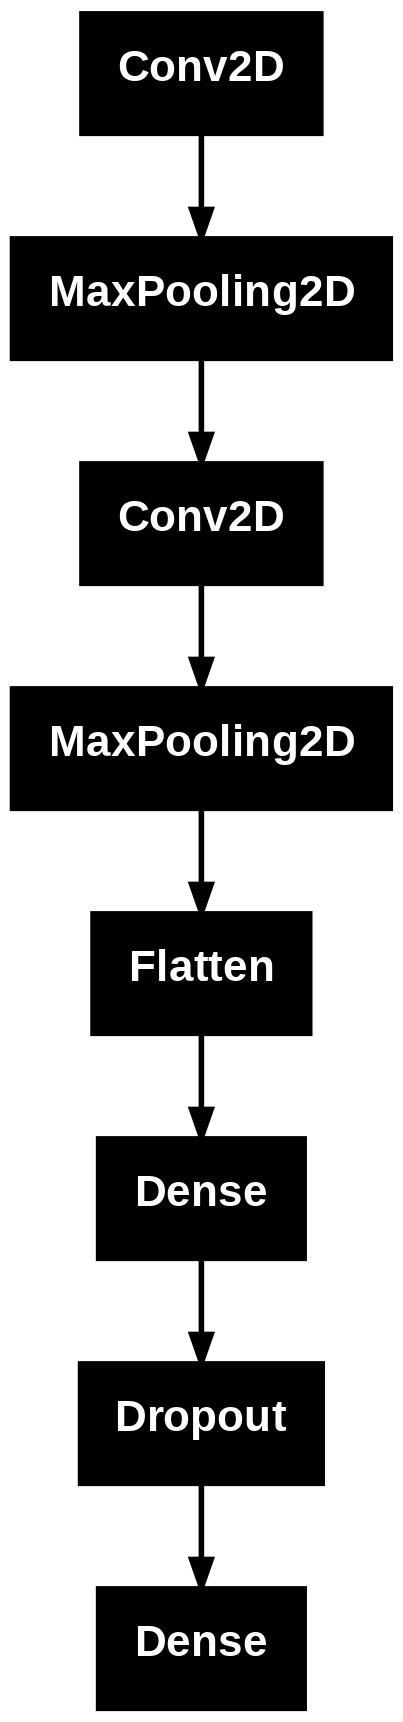

In [6]:
keras.utils.plot_model(model)

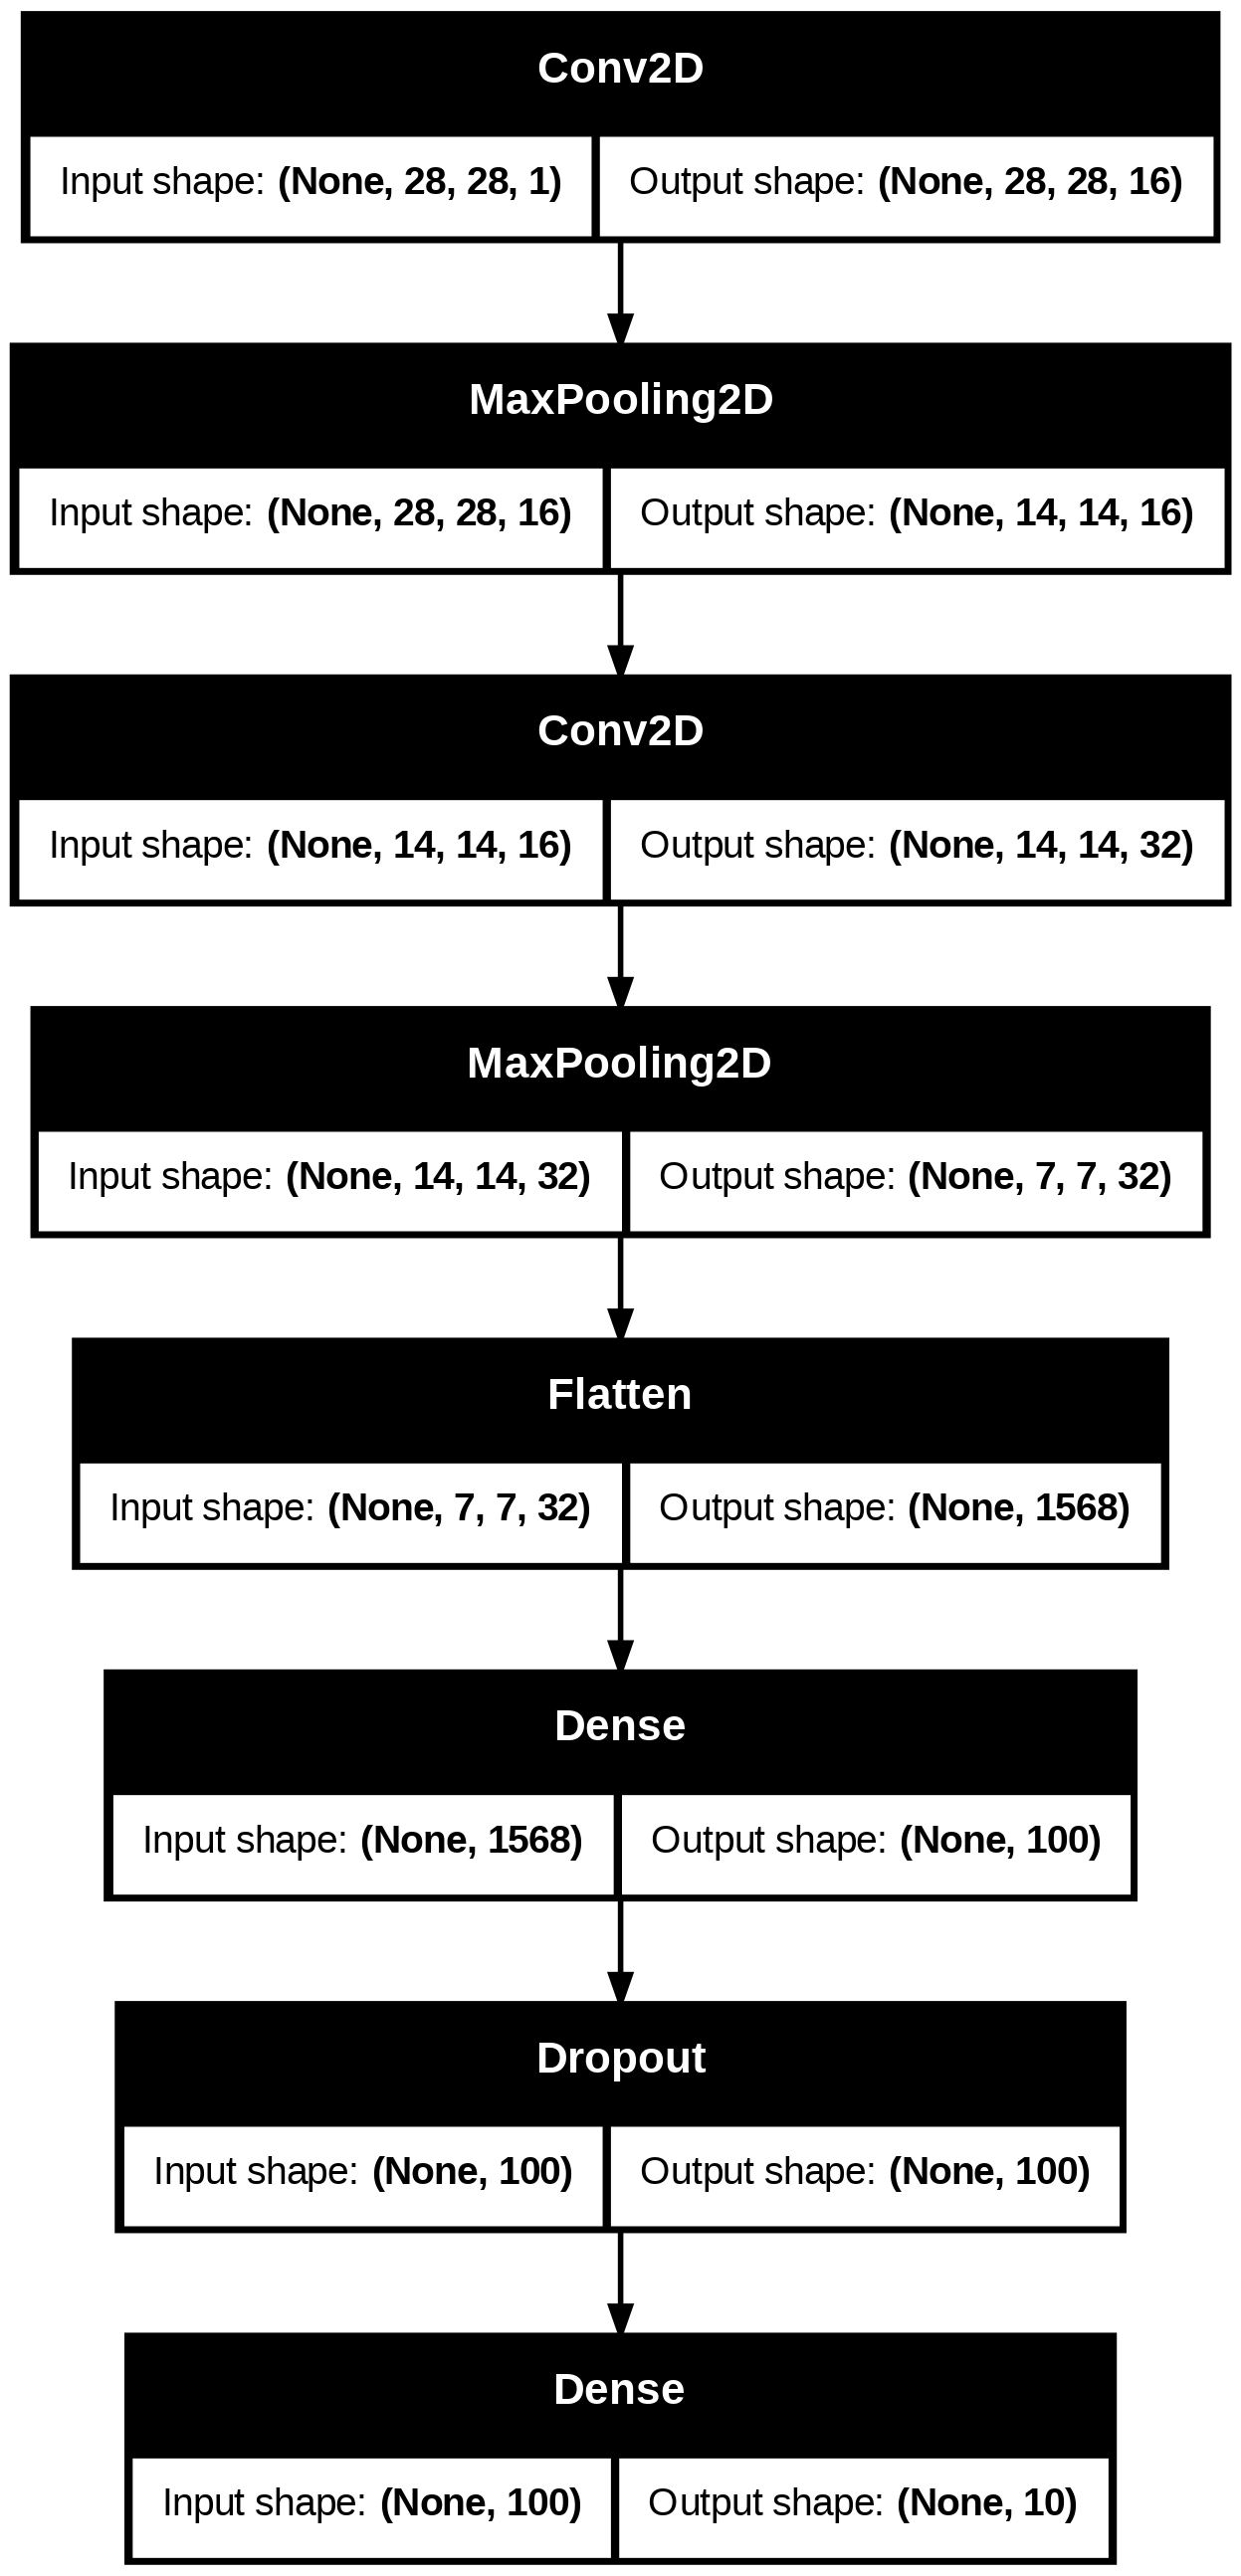

In [7]:
keras.utils.plot_model(model, show_shapes=True)

## 모델 컴파일과 훈련

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              # 현재 텐서플로 버전에서는 최대 풀링에 대한 결정적인 XLA 구현이 없기 때문에
              # enable_op_determinism() 호출로 인해 오류가 발생합니다.
              # 이를 피하기 위해 jit_compile 옵션을 False로 지정합니다.
              # https://github.com/tensorflow/tensorflow/issues/69417
              jit_compile=False)
checkpoint_cb = keras.callbacks.ModelCheckpoint('01_filters_16_32.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=15,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])



Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.7947 - loss: 0.5600 - val_accuracy: 0.8670 - val_loss: 0.3559
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8641 - loss: 0.3752 - val_accuracy: 0.8876 - val_loss: 0.2998
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8821 - loss: 0.3275 - val_accuracy: 0.8982 - val_loss: 0.2727
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8925 - loss: 0.2931 - val_accuracy: 0.9027 - val_loss: 0.2576
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9035 - loss: 0.2694 - val_accuracy: 0.9091 - val_loss: 0.2421
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9085 - loss: 0.2499 - val_accuracy: 0.9122 - val_loss: 0.2316
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9136 - loss: 0.2347 - val_accuracy: 0.9146 - val_loss: 0.2253
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9188 - loss: 0

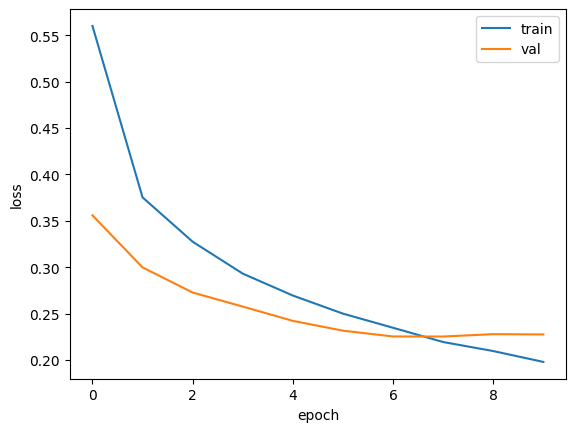

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

## Accuracy Curve

Train accuracy와 validation accuracy를 비교하여 일반화 성능과 과적합 여부를 확인합니다.


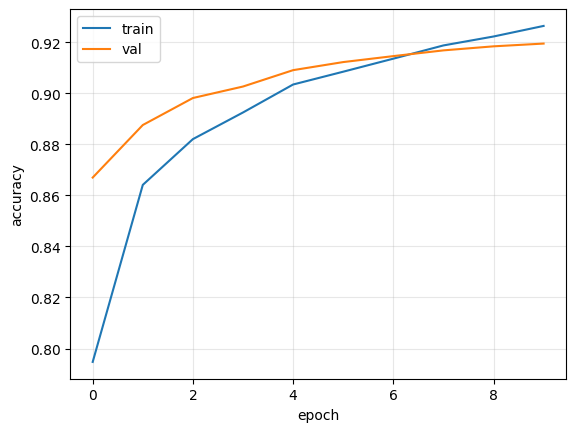

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'val'])
plt.grid(True, alpha=0.3)
plt.show()



In [11]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9168 - loss: 0.2253


[0.22526612877845764, 0.9168333411216736]

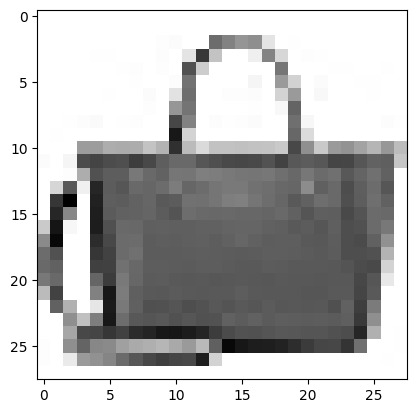

In [12]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [13]:
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
[[8.1914080e-20 6.7790341e-28 1.6565011e-22 2.7323368e-23 3.9973374e-21
  8.6442179e-23 6.8835281e-21 3.8597924e-21 1.0000000e+00 6.1933612e-24]]


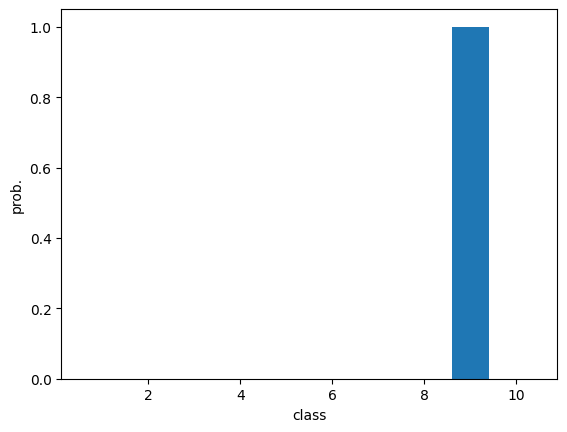

In [14]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [15]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [16]:
import numpy as np

print(classes[np.argmax(preds)])

가방


In [17]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [18]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9115 - loss: 0.2535


[0.25353652238845825, 0.9114999771118164]

## Confusion Matrix

Test set에서 어떤 class끼리 혼동되는지 확인합니다.


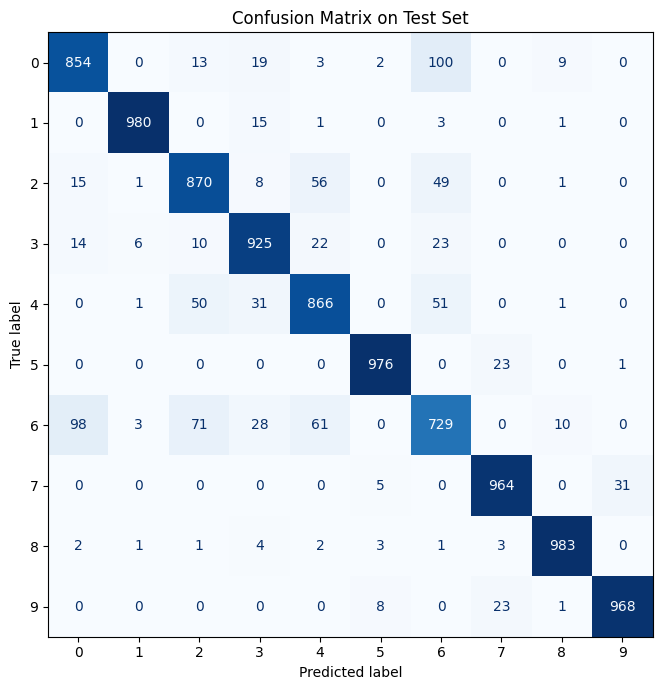

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

pred_labels = model.predict(test_scaled, verbose=0).argmax(axis=1)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    test_target,
    pred_labels,
    display_labels=range(10),
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()



## 실험 결과 저장

집계 노트북에서 비교할 수 있도록 validation/test 성능과 loss history를 JSON 파일로 저장합니다.


In [ ]:
import json
import os

val_loss, val_accuracy = model.evaluate(val_scaled, val_target, verbose=0)
test_loss, test_accuracy = model.evaluate(test_scaled, test_target, verbose=0)

try:
    RESULT_DIR = '/content/drive/MyDrive/CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)
except Exception:
    RESULT_DIR = './CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)

result = {
    'experiment_name': model.name,
    'parameter_count': int(model.count_params()),
    'epochs_ran': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_val_loss': float(val_loss),
    'final_val_accuracy': float(val_accuracy),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'train_loss_history': [float(x) for x in history.history['loss']],
    'val_loss_history': [float(x) for x in history.history['val_loss']],
    'train_accuracy_history': [float(x) for x in history.history['accuracy']],
    'val_accuracy_history': [float(x) for x in history.history['val_accuracy']],
}

result_path = os.path.join(RESULT_DIR, f'{model.name}.json')
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print('Saved result:', result_path)
print(result)



Saved result: /content/drive/MyDrive/CNN_fashion_results/exp01_filters_16_32.json
{'experiment_name': 'exp01_filters_16_32', 'parameter_count': 162710, 'epochs_ran': 10, 'best_val_loss': 0.22526612877845764, 'best_val_accuracy': 0.9194999933242798, 'final_val_loss': 0.22526612877845764, 'final_val_accuracy': 0.9168333411216736, 'test_loss': 0.25353652238845825, 'test_accuracy': 0.9114999771118164, 'train_loss_history': [0.5600419044494629, 0.3752490282058716, 0.3274584710597992, 0.29306265711784363, 0.26943275332450867, 0.24994772672653198, 0.23469509184360504, 0.21934078633785248, 0.20960529148578644, 0.19789054989814758], 'val_loss_history': [0.35589808225631714, 0.2997862696647644, 0.2726725935935974, 0.2575608491897583, 0.24214261770248413, 0.23158054053783417, 0.22531111538410187, 0.22526612877845764, 0.22781254351139069, 0.22750987112522125], 'train_accuracy_history': [0.7947499752044678, 0.8641250133514404, 0.8820624947547913, 0.8924999833106995, 0.9034583568572998, 0.9084791541

: 